<a href="https://colab.research.google.com/github/Ayushraj6942/SURGE-25-IIT-KANPUR-B2B-Brand-Equity/blob/main/Brand_equity_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

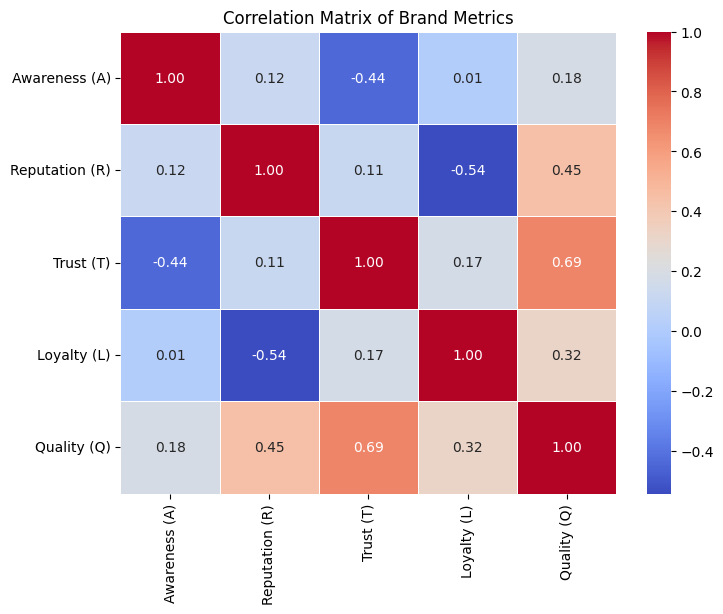

In [ ]:
# Step 1: Install necessary libraries (if not already installed)
!pip install seaborn pandas matplotlib

# Step 2: Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 3: Create the DataFrame
data = {
    'Company': ['Salesforce', 'Adobe', 'Intuit', 'Oracle', 'SAP'],
    'Awareness (A)': [79, 44, 45, 48, 47],
    'Reputation (R)': [50, 37, 29, 43, 80],
    'Trust (T)': [36, 60, 34, 80, 54.5],
    'Loyalty (L)': [44, 34, 53, 59, 33],
    'Quality (Q)': [58, 36, 27, 88, 63]
}

df = pd.DataFrame(data)

# Step 4: Drop 'Company' column for correlation computation
df_numeric = df.drop(columns=['Company'])

# Step 5: Compute correlation matrix
corr_matrix = df_numeric.corr()

# Step 6: Display the correlation matrix as a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Brand Metrics')
plt.show()



In [ ]:
import pandas as pd
from scipy.stats import pearsonr

# Subset of data
data = {
    'Trust': [36, 60, 34, 80, 54.5],
    'Reputation': [50, 37, 29, 43, 80],
    'Quality': [58, 36, 27, 88, 63],
    'Loyalty': [44, 34, 53, 59, 33]
}
df = pd.DataFrame(data)

# Test hypotheses
def corr_result(x, y):
    r, p = pearsonr(df[x], df[y])
    return f"{r:.2f}", f"{p:.3f}"

results = {
    "H1: Trust → Quality": corr_result('Trust', 'Quality'),
    "H2: Reputation → Quality": corr_result('Reputation', 'Quality'),
    "H3: Quality → Loyalty": corr_result('Quality', 'Loyalty')
}

# Display results in table
summary = pd.DataFrame(results, index=["Correlation (r)", "p-value"]).T
print(summary)


                         Correlation (r) p-value
H1: Trust → Quality                 0.69   0.198
H2: Reputation → Quality            0.45   0.452
H3: Quality → Loyalty               0.32   0.605


Intercept (β₀): -17.2334
Coefficients (β₁, β₂, β₃): [np.float64(0.0831), np.float64(-0.0444), np.float64(0.3228)]

Predicted Probabilities of High Brand Equity:
      Company  Predicted_Probability
0  Salesforce               0.998433
1       Adobe               0.009764
2      Intuit               0.001856
3      Oracle               0.999991
4         SAP               0.989959


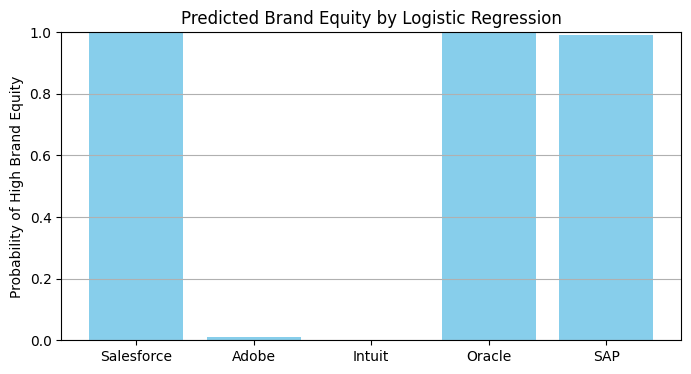

In [ ]:
# STEP 1: Install required packages (if running in Colab)
# You can skip this if already installed
# !pip install pandas scikit-learn matplotlib seaborn

# STEP 2: Import libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# STEP 3: Prepare your dataset
data = {
    'Company': ['Salesforce', 'Adobe', 'Intuit', 'Oracle', 'SAP'],
    'Awareness': [79, 44, 45, 48, 47],
    'Reputation': [50, 37, 29, 43, 80],
    'Trust': [36, 60, 34, 80, 54.5],
    'Loyalty': [44, 34, 53, 59, 33],
    'Quality': [58, 36, 27, 88, 63],
    # Define High Equity (1) or Not (0) manually for demo purposes
    # Here, assume Oracle and SAP have "high" equity (you can adjust this)
    'HighEquity': [1, 0, 0, 1, 1]
}

df = pd.DataFrame(data)

# STEP 4: Define inputs (features) and output (target)
X = df[['Awareness', 'Trust', 'Quality']]  # Independent variables
y = df['HighEquity']                       # Dependent variable (0 or 1)

# STEP 5: Create and train the logistic regression model
model = LogisticRegression()
model.fit(X, y)

# STEP 6: View estimated coefficients (β values)
intercept = model.intercept_[0]
coefficients = model.coef_[0]

print("Intercept (β₀):", round(intercept, 4))
print("Coefficients (β₁, β₂, β₃):", [round(b, 4) for b in coefficients])

# STEP 7: Predict probabilities
df['Predicted_Probability'] = model.predict_proba(X)[:, 1]
print("\nPredicted Probabilities of High Brand Equity:")
print(df[['Company', 'Predicted_Probability']])

# STEP 8: Optional - Plot
plt.figure(figsize=(8, 4))
plt.bar(df['Company'], df['Predicted_Probability'], color='skyblue')
plt.ylim(0, 1)
plt.ylabel("Probability of High Brand Equity")
plt.title("Predicted Brand Equity by Logistic Regression")
plt.grid(True, axis='y')
plt.show()


In [ ]:
# Step 2: Import libraries
import spacy
import networkx as nx
import pandas as pd
import re
from collections import defaultdict, Counter
from sklearn.preprocessing import StandardScaler

In [ ]:
# Step 3: Load spaCy model
nlp = spacy.load("en_core_web_sm")

In [ ]:
# Step 4: Define the text data
texts = {
    "Adobe": """
       We're thrilled to welcome Louise Pentland as our Chief Legal Officer. 👏 We're honored to have her incisive wit, expertise and leadership on board at Adobe. Please join us in giving her a very warm welcome!

Louise Pentland
Louise Pentland
• 3rd+
3rd+
Chief Legal Officer | P&L Leader, Corporate Affairs, Board Member | Adobe, Roku, Walt Disney, PayPal, Nokia
Chief Legal Officer | P&L Leader, Corporate Affairs, Board Member | Adobe, Roku, Walt Disney, PayPal, Nokia
1w •
1 week ago • Visible to anyone on or off LinkedIn
Follow
As I reflect on my first four weeks at Adobe, two words come to mind – exhilarating and grateful.


Adobe is not only at the forefront of pioneering transformative technologies – it's doing so with creativity, purpose and innovation at its core. At this pivotal moment for tech and AI, I’m especially energized to be part of a company that leads with values and is deeply committed to responsible innovation.
I’m honored and grateful to be working alongside world-class talent to lead Adobe’s global legal and policy work. We have a tremendous opportunity ahead to ensure we continue driving breakthrough innovations while also building trust and integrity into everything we do.
Thank you to everyone who’s given me such a warm Adobe welcome. I’m inspired by the people and culture here, and I can’t wait for all that is ahead as we build the future together.
    """,
    "Salesforce": """
       In India, climate action is being reimagined — where AI meets community to drive real change 🌏
At Salesforce India, we’re supporting bold, local solutions:
⚡ Clean solar power in Telangana
📚 100,000+ students learning green & AI skills
🌱 Communities leading with technology and purpose
From microgrids in Jangaon to climate classrooms in Hyderabad, we’re proud to stand with India’s vision for a sustainable future — powered by agentic AI and built from the ground up.💙
Discover the full story 👉 https://lnkd.in/gVhkqHng


With Sanket Atal Kiranmayi B Tim Christophersen
Activate to view larger image,
    """,
    "Oracle": """
     I wanted to take a moment to share how grateful and energized we all are here at Oracle as we wrap our FY25.


This past year, we saw remarkable momentum across Oracle Cloud Applications, with revenue up 12% and Cloud ERP revenue up 22%. But our CEO, Safra Catz, may have said it best, “Oracle is well on its way to being not only the world’s largest cloud application company but also one of the world’s largest cloud infrastructure companies.”


From finance and HR to supply chain and marketing, organizations around the world turn to Oracle to operate smarter, faster, and with more resilience. Customers like EssilorLuxottica, Nokia, Virgin Media O2, FirstEnergy, Florida's Natural Growers, MGM Resorts International, MTN, and so many more are modernizing with Fusion Applications at the core of their businesses.


To our customers, partners, and employees: THANK YOU. Your trust and collaboration fuel our innovation. We look forward to everything that comes next, because our success is driven by your success.
Activate to view larger image,


    """,
    "Intuit": """
        In a new video series, Businesses Defying the Odds, I’ll be introducing you to inspiring Intuit customers I’ve met. Some of their greatest wins came after self doubt and being told it can’t be done. But they faced their obstacles with grit and overcame them.

When I think about my own life, there were many times I was underestimated. It inspired me to work harder and prove what’s possible. When I was kicked out of school with bad grades, or struggled in jobs, those experiences were turning points. When these moments happen, we often feel alone. We need to do a better job of sharing challenges, celebrating the moments when we overcame them and helping each other along the way.

The first entrepreneur I talked with is Keila Hill-Trawick, CPA, MBA. Today, Keila is in high demand as a CPA but she wasn’t always confident her business would succeed. She shares a valuable lesson in how to build a thriving company:
    """,
    "SAP": """
        Met my younger self for coffee this morning.

They told us they employ 25 people and have acquired six new customers.
We told them they have a lot more people to meet as we are now a global enterprise with 109,000+ employees.

They told us SAP has moved its headquarters to rented office space in Walldorf, Germany.
We told them that was just the start and to look forward to having offices in more than 78 countries.

They told us they acquired their very first computer with plans to build our core software.
We told them there is so much more to come, because we are the world’s largest provider of enterprise application software.

We finish our coffee and agree to meet again in another 5 years.
    """
}

In [ ]:
# Step 5: Text preprocessing
def preprocess(text):
    doc = nlp(text.lower())
    return [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]


In [ ]:
# Step 6: Build co-occurrence network
def build_network(tokens_list, window_size=3):
    G = nx.Graph()
    for tokens in tokens_list:
        for i in range(len(tokens)):
            for j in range(i+1, min(i + window_size, len(tokens))):
                w1, w2 = tokens[i], tokens[j]
                if w1 != w2:
                    if G.has_edge(w1, w2):
                        G[w1][w2]['weight'] += 1
                    else:
                        G.add_edge(w1, w2, weight=1)
    return G

In [ ]:
# Step 7: Compute SBS components
results = []
scalers = StandardScaler()
brands = list(texts.keys())
components = {"prevalence": [], "diversity": [], "connectivity": []}

for brand, text in texts.items():
    tokens = preprocess(text)
    G = build_network([tokens])

    # Prevalence
    word_count = len(tokens)
    freq = tokens.count(brand.lower())
    prevalence = freq / word_count if word_count else 0
    components["prevalence"].append(prevalence)

    # Diversity = Degree centrality
    degree_centrality = nx.degree_centrality(G)
    diversity = degree_centrality.get(brand.lower(), 0)
    components["diversity"].append(diversity)

    # Connectivity = Betweenness centrality
    try:
        between = nx.betweenness_centrality(G, normalized=True)
        connectivity = between.get(brand.lower(), 0)
    except:
        connectivity = 0
    components["connectivity"].append(connectivity)

In [ ]:
# Step 8: Normalize (z-scores)
sbs_df = pd.DataFrame(components, index=brands)
sbs_z = pd.DataFrame(scalers.fit_transform(sbs_df), columns=sbs_df.columns, index=sbs_df.index)
sbs_z["SBS"] = sbs_z.sum(axis=1)


In [ ]:
# Step 9: Output
print("📊 Final SBS Scores:")
print(sbs_z.sort_values("SBS", ascending=False).round(3))

📊 Final SBS Scores:
            prevalence  diversity  connectivity    SBS
Adobe            1.512      1.541         1.497  4.550
Oracle           0.878      0.819         0.908  2.605
SAP             -0.688     -0.567        -0.829 -2.085
Salesforce      -0.743     -0.784        -0.841 -2.368
Intuit          -0.958     -1.010        -0.734 -2.702



Salesforce:
Mean BES: 54.81
10th percentile: 52.35
90th percentile: 57.26
Probability BES < 60: 99.5%

Adobe:
Mean BES: 42.55
10th percentile: 40.04
90th percentile: 45.11
Probability BES < 60: 100.0%

Intuit:
Mean BES: 38.41
10th percentile: 35.85
90th percentile: 40.89
Probability BES < 60: 100.0%

Oracle:
Mean BES: 63.87
10th percentile: 61.39
90th percentile: 66.36
Probability BES < 60: 2.2%

SAP:
Mean BES: 53.88
10th percentile: 51.34
90th percentile: 56.33
Probability BES < 60: 99.9%


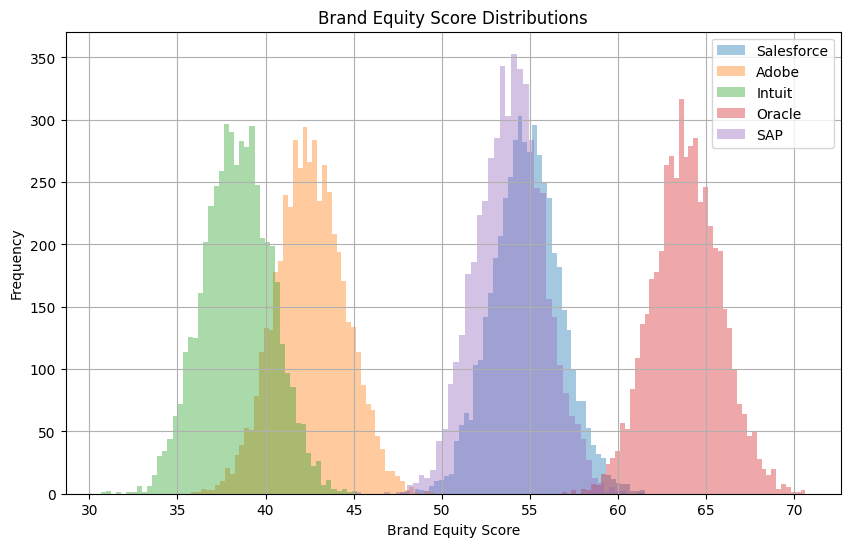

In [ ]:
# 📊 Monte Carlo Simulation for B2B Brand Equity Optimization

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Step 1: Load Perception Data ---
data = {
    'Company': ['Salesforce', 'Adobe', 'Intuit', 'Oracle', 'SAP'],
    'Awareness': [79, 44, 45, 48, 47],
    'Reputation': [50, 37, 29, 43, 80],
    'Trust': [36, 60, 34, 80, 54.5],
    'Loyalty': [44, 34, 53, 59, 33],
    'Quality': [58, 36, 27, 88, 63]
}
df = pd.DataFrame(data)

# --- Step 2: Define Simulation Function ---
def simulate_brand_equity(company_row, n=5000):
    A_mu, A_sigma = company_row['Awareness'], 5
    R_mu, R_sigma = company_row['Reputation'], 4
    T_min, T_mode, T_max = company_row['Trust']-6, company_row['Trust'], company_row['Trust']+6
    L_mu, L_sigma = company_row['Loyalty'], 5
    Q_mu, Q_sigma = company_row['Quality'], 4

    A = np.random.normal(A_mu, A_sigma, n)
    R = np.random.normal(R_mu, R_sigma, n)
    T = np.random.triangular(T_min, T_mode, T_max, n)
    L = np.random.normal(L_mu, L_sigma, n)
    Q = np.random.normal(Q_mu, Q_sigma, n)

    # Brand Equity Score = weighted sum
    BES = 0.25*A + 0.15*R + 0.2*T + 0.2*L + 0.2*Q
    return BES

# --- Step 3: Run Simulations for All Companies ---
results = {}
for i, row in df.iterrows():
    company = row['Company']
    bes_samples = simulate_brand_equity(row)
    results[company] = bes_samples

    # Summary stats
    print(f"\n{company}:")
    print(f"Mean BES: {np.mean(bes_samples):.2f}")
    print(f"10th percentile: {np.percentile(bes_samples, 10):.2f}")
    print(f"90th percentile: {np.percentile(bes_samples, 90):.2f}")
    print(f"Probability BES < 60: {np.mean(bes_samples < 60) * 100:.1f}%")

# --- Step 4: Visualize One Example ---
plt.figure(figsize=(10,6))
for company in results:
    plt.hist(results[company], bins=50, alpha=0.4, label=company)

plt.title("Brand Equity Score Distributions")
plt.xlabel("Brand Equity Score")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()
